# SHAP Explainability Analysis - Karachi AQI Prediction

##  1. Imports & Configuration

In [5]:
# Core libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ML libraries
import mlflow
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

# SHAP
import shap

# MongoDB
from pymongo import MongoClient
from dotenv import load_dotenv

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
shap.initjs()  # Initialize JS for interactive plots

print("✅ All libraries imported successfully")
print(f"SHAP version: {shap.__version__}")
print(f"Notebook generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All libraries imported successfully
SHAP version: 0.50.0
Notebook generated: 2026-02-16 22:28:47


In [6]:
# Configuration
load_dotenv()

MONGO_URI = os.getenv("MONGODB_URI")
DB_NAME = os.getenv("MONGODB_DB")
COLLECTION = os.getenv("MONGODB_COLLECTION")

FEATURE_COLUMNS = [
    "pm2_5", "pm10", "no2", "o3", "co", "so2",
    "temperature", "humidity", "wind_speed",
    "hour", "day", "month", "day_of_week",
    "aqi_lag_1", "aqi_lag_24",
    "aqi_change_1h", "aqi_change_24h",
]

TARGET_COLUMN = "target_aqi"

# Create output directory for figures
os.makedirs('figures/shap', exist_ok=True)

print(f"MongoDB Database: {DB_NAME}")
print(f"Collection: {COLLECTION}")
print(f"Total features: {len(FEATURE_COLUMNS)}")

MongoDB Database: aqi_feature_store
Collection: aqi_features_v1
Total features: 17


## 2. Data Loading & Preparation

In [7]:
# Connect to MongoDB and load data
print("📊 Loading data from MongoDB...")

client = MongoClient(MONGO_URI)
collection = client[DB_NAME][COLLECTION]

# Load historical training data
cursor = collection.find({"dataset_type": "historical"})
df = pd.DataFrame(list(cursor))

if df.empty:
    raise ValueError("❌ No historical data found! Run backfill.py first.")

# Drop MongoDB ID
df = df.drop(columns=["_id"], errors="ignore")

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"✅ Loaded {len(df):,} records")
print(f"📅 Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"⏱️  Duration: {(df['timestamp'].max() - df['timestamp'].min()).days} days")

📊 Loading data from MongoDB...
✅ Loaded 2,151 records
📅 Date range: 2025-11-17 00:00:00+00:00 to 2026-02-14 14:00:00+00:00
⏱️  Duration: 89 days


In [10]:
# Data quality checks
print("\nData Quality Assessment:")
print("="*80)

# Check for required columns
required_cols = FEATURE_COLUMNS + [TARGET_COLUMN]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    print(f"WARNING: Missing columns: {missing_cols}")
else:
    print("All required columns present")

# Check for missing values
missing_summary = df[required_cols].isnull().sum()
if missing_summary.sum() > 0:
    print(f"\nMissing values detected:")
    print(missing_summary[missing_summary > 0])
else:
    print("No missing values in required columns")

# Clean data
df_clean = df[required_cols].dropna().copy()
print(f"\nClean dataset: {len(df_clean):,} rows ({len(df_clean)/len(df)*100:.1f}% of original)")

# Basic statistics
print(f"\nTarget (AQI) Statistics:")
print(f"   Mean: {df_clean[TARGET_COLUMN].mean():.2f}")
print(f"   Median: {df_clean[TARGET_COLUMN].median():.2f}")
print(f"   Std: {df_clean[TARGET_COLUMN].std():.2f}")
print(f"   Min: {df_clean[TARGET_COLUMN].min():.2f}")
print(f"   Max: {df_clean[TARGET_COLUMN].max():.2f}")


Data Quality Assessment:
All required columns present
No missing values in required columns

Clean dataset: 2,151 rows (100.0% of original)

Target (AQI) Statistics:
   Mean: 107.34
   Median: 105.00
   Std: 23.66
   Min: 63.00
   Max: 156.00


In [11]:
# Prepare features and target
X = df_clean[FEATURE_COLUMNS]
y = df_clean[TARGET_COLUMN]

# Time-based split (80/20)
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"\n📊 Dataset Split:")
print(f"   Training: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Testing:  {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"   Features: {X.shape[1]}")


📊 Dataset Split:
   Training: 1,720 samples (80.0%)
   Testing:  431 samples (20.0%)
   Features: 17


## 3. Model Training (for SHAP Analysis)

In [12]:
# Train GradientBoosting model (typically the best performer)
print("🚀 Training GradientBoosting model for SHAP analysis...\n")

model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=4,
    subsample=0.8,
    random_state=42,
    verbose=1
)

model.fit(X_train, y_train)

# Evaluate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

print(f"\n📊 Model Performance:")
print(f"   Train RMSE: {train_rmse:.2f}")
print(f"   Test RMSE:  {test_rmse:.2f}")
print(f"   Test MAE:   {test_mae:.2f}")
print(f"   Test R²:    {test_r2:.3f}")

if test_r2 < 0.7:
    print("\n⚠️ WARNING: Low R² score. Consider:")
    print("   1. More training data")
    print("   2. Feature engineering")
    print("   3. Hyperparameter tuning")
elif test_r2 > 0.95:
    print("\n⚠️ WARNING: Very high R². Check for data leakage!")
else:
    print("\n✅ Model performance looks good!")

🚀 Training GradientBoosting model for SHAP analysis...

      Iter       Train Loss      OOB Improve   Remaining Time 
         1         554.0987          57.7427            7.19s
         2         493.9531          23.3125            5.16s
         3         447.8175          53.9339            4.29s
         4         409.6496          61.3312            3.83s
         5         368.1523          27.7557            3.57s
         6         340.6026          64.9436            3.43s
         7         312.6963          48.0599            3.21s
         8         279.0777           9.4213            3.07s
         9         253.4771          27.5052            2.96s
        10         228.6151          17.8800            2.89s
        20          86.6354           9.2709            2.36s
        30          34.6221           3.3663            2.16s
        40          14.6492           0.6968            2.37s
        50           7.3534           0.9262            2.18s
        60   

## 4. SHAP


In [13]:
# Create SHAP explainer
print("🔬 Creating SHAP explainer...\n")

# For tree-based models, use TreeExplainer (fast and exact)
explainer = shap.TreeExplainer(model)

# Compute SHAP values for test set
# Use a sample to speed up (adjust based on your dataset size)
SAMPLE_SIZE = min(500, len(X_test))
X_test_sample = X_test.sample(n=SAMPLE_SIZE, random_state=42)

print(f"Computing SHAP values for {SAMPLE_SIZE} test samples...")
print("(This may take 1-2 minutes)\n")

shap_values = explainer.shap_values(X_test_sample)

print(f"✅ SHAP values computed!")
print(f"   Shape: {shap_values.shape}")
print(f"   Mean absolute SHAP: {np.abs(shap_values).mean():.3f}")

🔬 Creating SHAP explainer...

Computing SHAP values for 431 test samples...
(This may take 1-2 minutes)

✅ SHAP values computed!
   Shape: (431, 17)
   Mean absolute SHAP: 1.194


## 5. Global Feature Importance

**Question:** Which features matter most for AQI prediction across all samples?

📊 Generating Feature Importance Bar Chart...



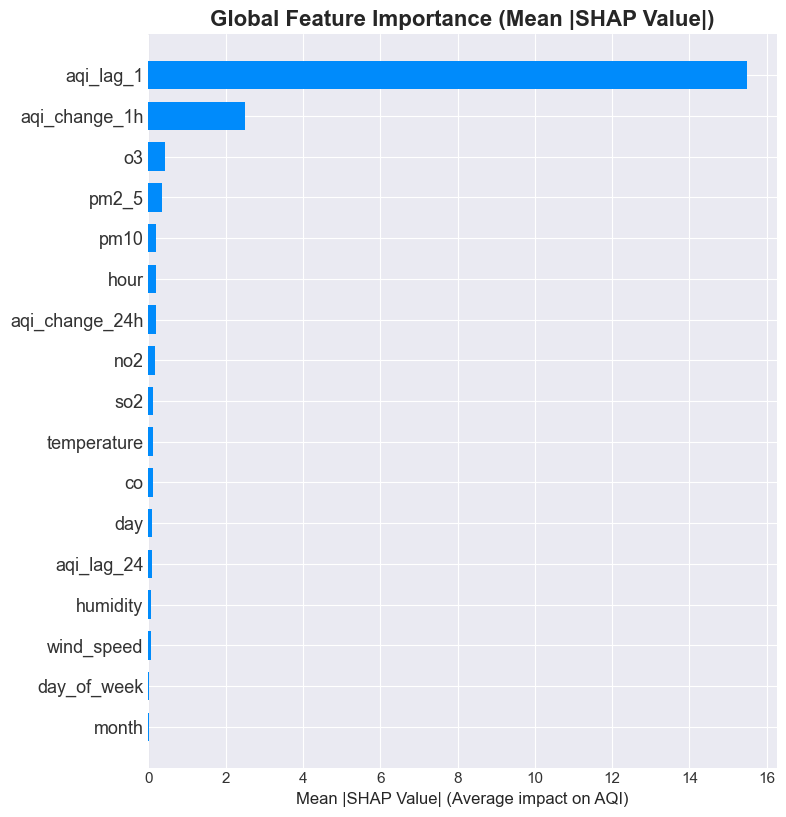

✅ Saved: figures/shap/01_feature_importance_bar.png

🏆 Top 10 Most Important Features:
aqi_lag_1            → 15.4895
aqi_change_1h        → 2.5023
o3                   → 0.4301
pm2_5                → 0.3632
pm10                 → 0.2090
hour                 → 0.1989
aqi_change_24h       → 0.1876
no2                  → 0.1844
so2                  → 0.1290
temperature          → 0.1231


In [14]:
# Plot 1: Feature Importance Bar Chart
print("📊 Generating Feature Importance Bar Chart...\n")

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("Global Feature Importance (Mean |SHAP Value|)", fontsize=16, fontweight='bold')
plt.xlabel("Mean |SHAP Value| (Average impact on AQI)", fontsize=12)
plt.tight_layout()
plt.savefig('figures/shap/01_feature_importance_bar.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: figures/shap/01_feature_importance_bar.png")

# Calculate and display importance scores
importance = np.abs(shap_values).mean(axis=0)
feature_importance_df = pd.DataFrame({
    'feature': X_test_sample.columns,
    'importance': importance
}).sort_values('importance', ascending=False)

print("\n🏆 Top 10 Most Important Features:")
print("="*60)
for idx, row in feature_importance_df.head(10).iterrows():
    print(f"{row['feature']:20s} → {row['importance']:.4f}")


📊 Generating SHAP Summary Plot (Beeswarm)...



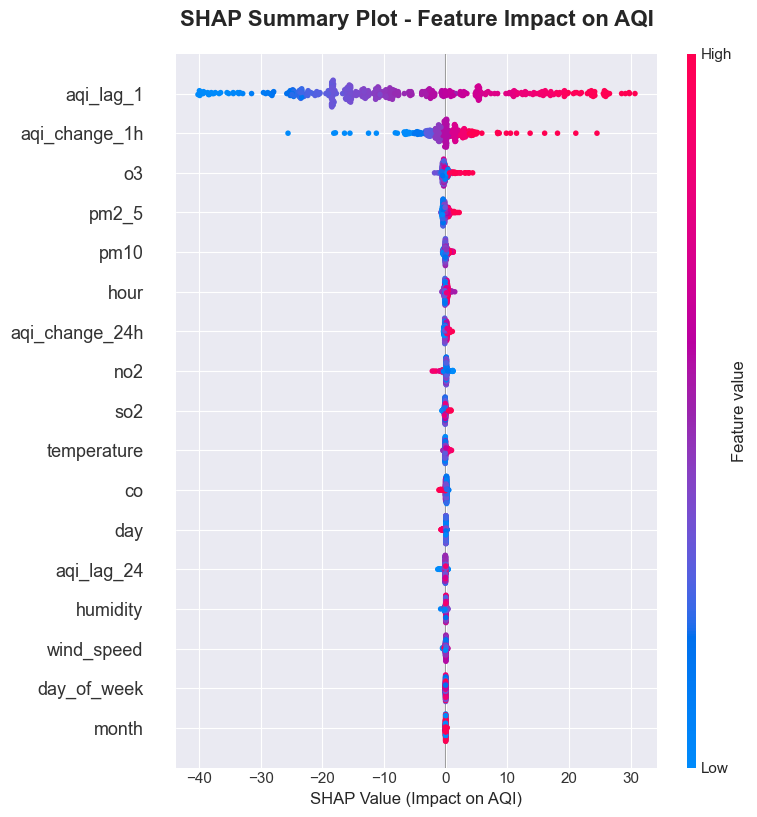

✅ Saved: figures/shap/02_summary_beeswarm.png

💡 Interpretation:
   - Each dot = one prediction
   - X-axis = impact on AQI (positive = increases AQI)
   - Color = feature value (red = high, blue = low)
   - Position = how much this feature pushed prediction up/down


In [15]:
# Plot 2: SHAP Summary Plot (Beeswarm)
print("\n📊 Generating SHAP Summary Plot (Beeswarm)...\n")

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Summary Plot - Feature Impact on AQI", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("SHAP Value (Impact on AQI)", fontsize=12)
plt.tight_layout()
plt.savefig('figures/shap/02_summary_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: figures/shap/02_summary_beeswarm.png")
print("\n💡 Interpretation:")
print("   - Each dot = one prediction")
print("   - X-axis = impact on AQI (positive = increases AQI)")
print("   - Color = feature value (red = high, blue = low)")
print("   - Position = how much this feature pushed prediction up/down")

## 6. Feature Dependence Plots

**Question:** How does the relationship between a feature and AQI look like?

📊 Generating Dependence Plots for top 6 features...



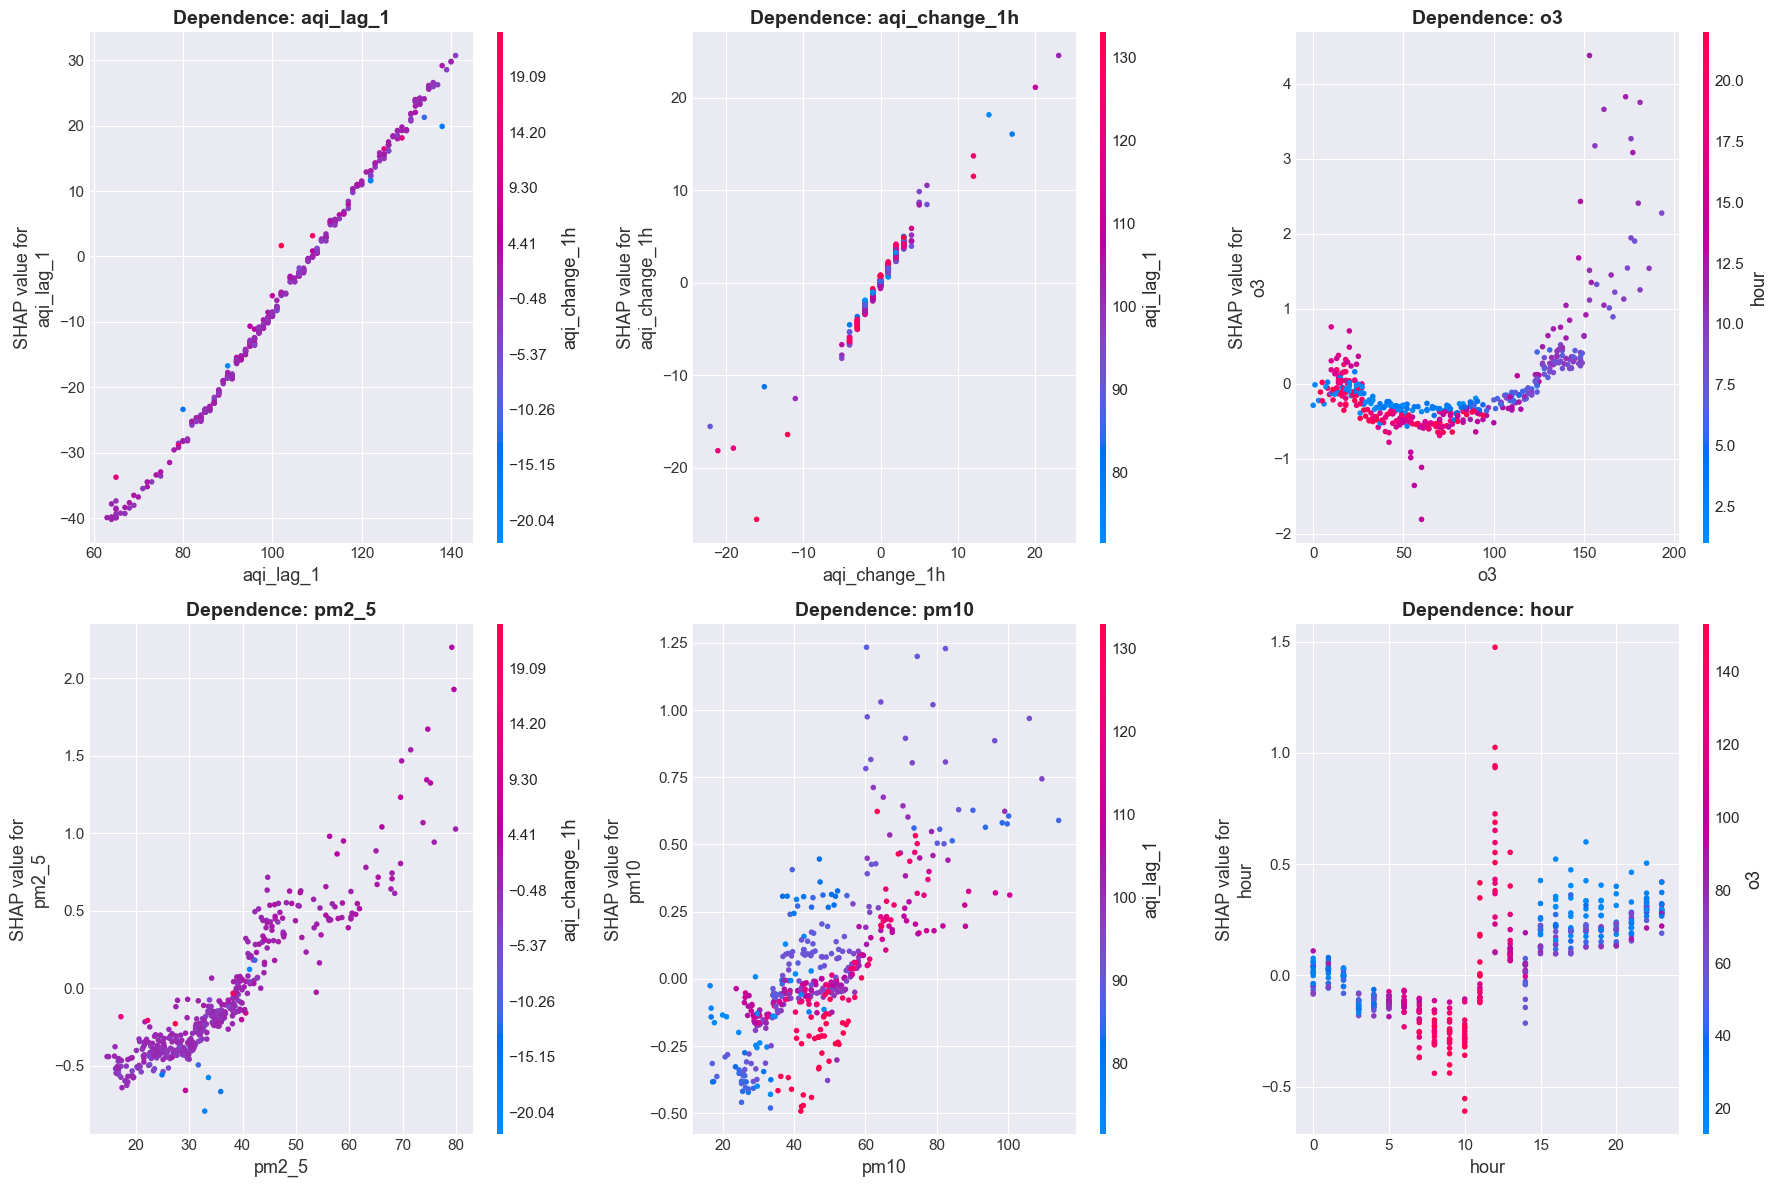

✅ Saved: figures/shap/03_dependence_plots.png

💡 Interpretation:
   - X-axis = feature value
   - Y-axis = SHAP value (impact on AQI)
   - Color = interaction feature (auto-selected by SHAP)
   - Trend shows how feature affects predictions


In [16]:
# Dependence plots for top 6 features
top_features = feature_importance_df.head(6)['feature'].tolist()

print(f"📊 Generating Dependence Plots for top {len(top_features)} features...\n")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    feature_idx = list(X_test_sample.columns).index(feature)
    
    plt.sca(axes[idx])
    shap.dependence_plot(
        feature_idx,
        shap_values,
        X_test_sample,
        show=False,
        ax=axes[idx]
    )
    axes[idx].set_title(f"Dependence: {feature}", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/shap/03_dependence_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: figures/shap/03_dependence_plots.png")
print("\n💡 Interpretation:")
print("   - X-axis = feature value")
print("   - Y-axis = SHAP value (impact on AQI)")
print("   - Color = interaction feature (auto-selected by SHAP)")
print("   - Trend shows how feature affects predictions")

## 7. Local Explanations - Individual Predictions

**Question:** Why did the model predict THIS specific AQI value?

📍 Selected Examples:
   High AQI: 141.0 (sample 95)
   Low AQI:  63.0 (sample 53)

📊 Generating Force Plot for HIGH AQI instance...


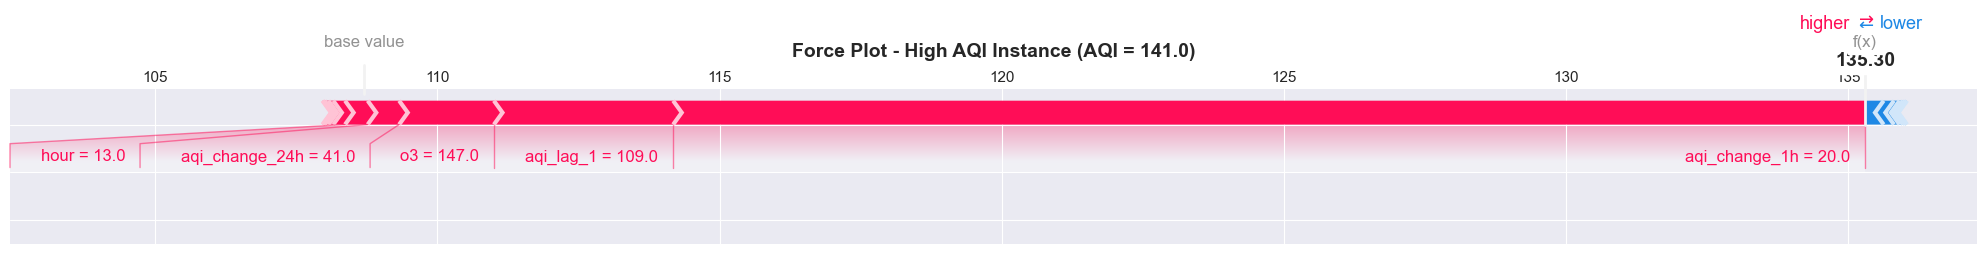

✅ Saved: figures/shap/04_force_plot_high_aqi.png


In [17]:
# Find examples: High AQI and Low AQI
y_test_sample = y_test.loc[X_test_sample.index]

high_aqi_idx = y_test_sample.idxmax()
low_aqi_idx = y_test_sample.idxmin()

high_aqi_sample_idx = X_test_sample.index.get_loc(high_aqi_idx)
low_aqi_sample_idx = X_test_sample.index.get_loc(low_aqi_idx)

print(f"📍 Selected Examples:")
print(f"   High AQI: {y_test_sample.loc[high_aqi_idx]:.1f} (sample {high_aqi_sample_idx})")
print(f"   Low AQI:  {y_test_sample.loc[low_aqi_idx]:.1f} (sample {low_aqi_sample_idx})")

# Force plot for HIGH AQI
print("\n📊 Generating Force Plot for HIGH AQI instance...")

shap.force_plot(
    explainer.expected_value,
    shap_values[high_aqi_sample_idx, :],
    X_test_sample.iloc[high_aqi_sample_idx, :],
    matplotlib=True,
    show=False,
    figsize=(20, 3)
)
plt.title(f"Force Plot - High AQI Instance (AQI = {y_test_sample.loc[high_aqi_idx]:.1f})", 
          fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('figures/shap/04_force_plot_high_aqi.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: figures/shap/04_force_plot_high_aqi.png")


📊 Generating Force Plot for LOW AQI instance...


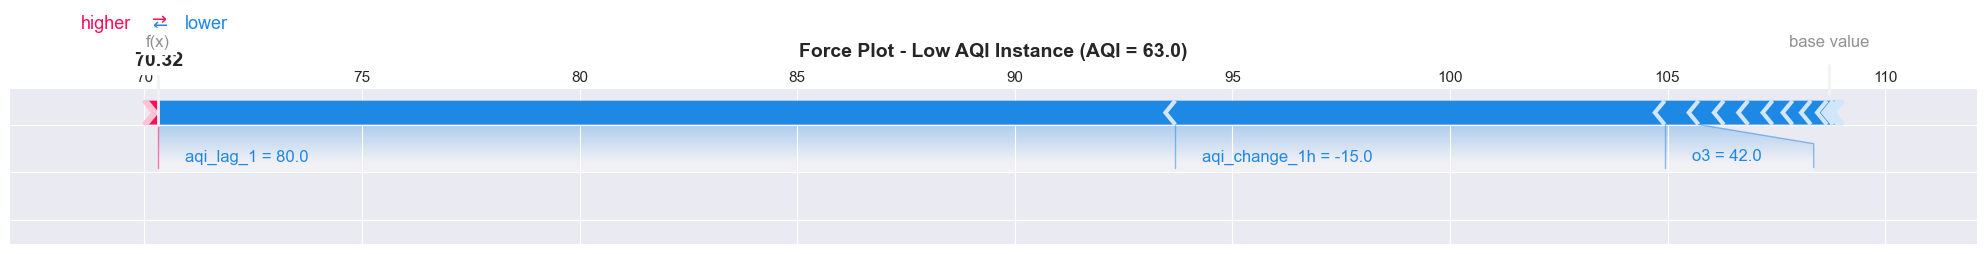

✅ Saved: figures/shap/05_force_plot_low_aqi.png

💡 Interpretation:
   - Base value = average prediction
   - Red arrows = features pushing AQI higher
   - Blue arrows = features pushing AQI lower
   - Arrow width = magnitude of impact


In [18]:
# Force plot for LOW AQI
print("\n📊 Generating Force Plot for LOW AQI instance...")

shap.force_plot(
    explainer.expected_value,
    shap_values[low_aqi_sample_idx, :],
    X_test_sample.iloc[low_aqi_sample_idx, :],
    matplotlib=True,
    show=False,
    figsize=(20, 3)
)
plt.title(f"Force Plot - Low AQI Instance (AQI = {y_test_sample.loc[low_aqi_idx]:.1f})", 
          fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('figures/shap/05_force_plot_low_aqi.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: figures/shap/05_force_plot_low_aqi.png")

print("\n💡 Interpretation:")
print("   - Base value = average prediction")
print("   - Red arrows = features pushing AQI higher")
print("   - Blue arrows = features pushing AQI lower")
print("   - Arrow width = magnitude of impact")


📊 Generating Waterfall Plots...



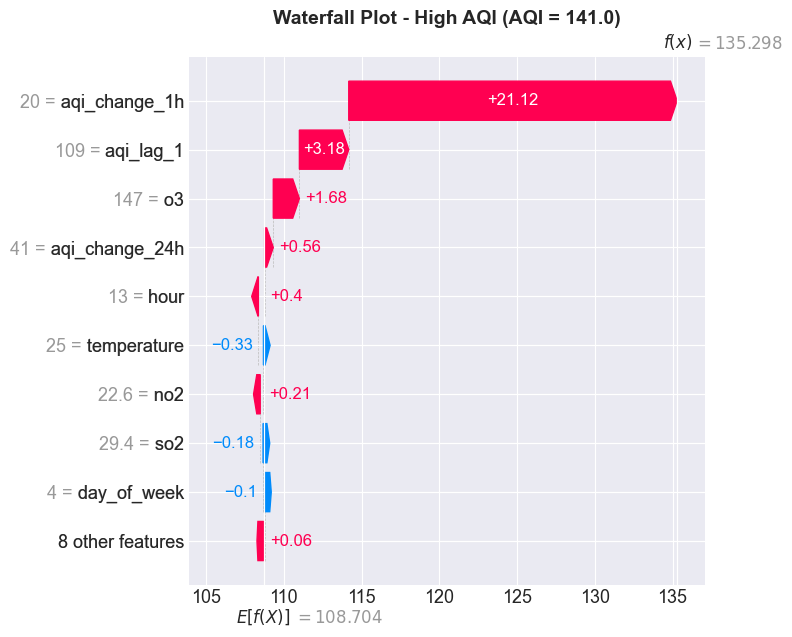

✅ Saved: figures/shap/06_waterfall_high_aqi.png


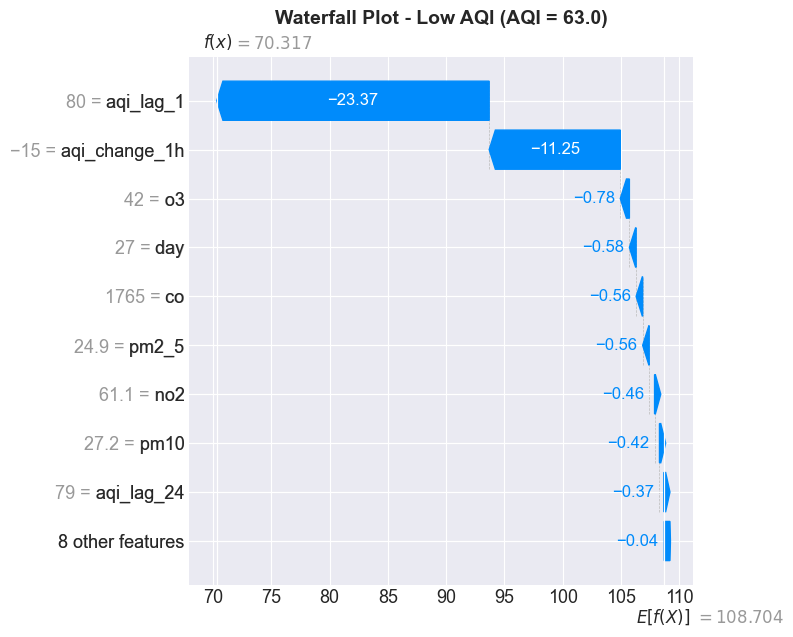

✅ Saved: figures/shap/07_waterfall_low_aqi.png


In [25]:
# Waterfall plots (cumulative effect)
print("\n📊 Generating Waterfall Plots...\n")

# ⭐ FIX: Extract scalar base_value properly
base_value = (
    explainer.expected_value[0] 
    if isinstance(explainer.expected_value, np.ndarray) 
    else explainer.expected_value
)

# High AQI Waterfall
plt.figure(figsize=(12, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_aqi_sample_idx],
        base_values=base_value,  # ⭐ Use scalar base_value
        data=X_test_sample.iloc[high_aqi_sample_idx],
        feature_names=X_test_sample.columns.tolist()
    ),
    show=False
)
plt.title(f"Waterfall Plot - High AQI (AQI = {y_test_sample.loc[high_aqi_idx]:.1f})", 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/shap/06_waterfall_high_aqi.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: figures/shap/06_waterfall_high_aqi.png")

# Low AQI Waterfall
plt.figure(figsize=(12, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[low_aqi_sample_idx],
        base_values=base_value,  # ⭐ Use scalar base_value
        data=X_test_sample.iloc[low_aqi_sample_idx],
        feature_names=X_test_sample.columns.tolist()
    ),
    show=False
)
plt.title(f"Waterfall Plot - Low AQI (AQI = {y_test_sample.loc[low_aqi_idx]:.1f})", 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/shap/07_waterfall_low_aqi.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: figures/shap/07_waterfall_low_aqi.png")

## 8. Feature Interactions

**Question:** How do features work together to affect AQI?

📊 Analyzing interaction between: aqi_lag_1 and aqi_change_1h



<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

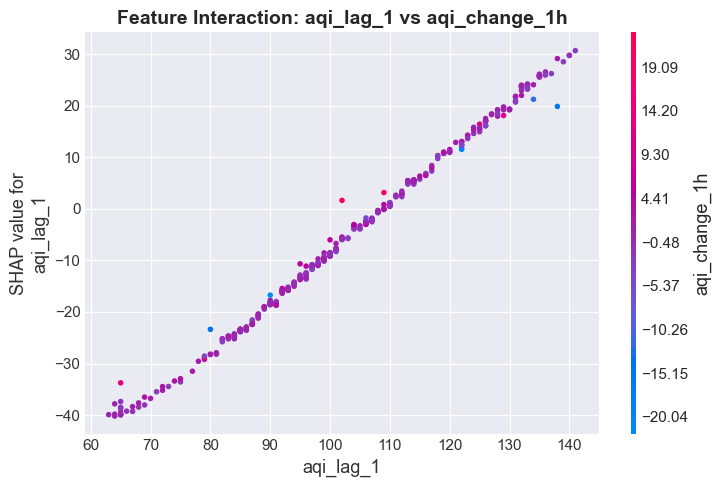

✅ Saved: figures/shap/08_feature_interaction.png

💡 Interpretation:
   - X-axis = aqi_lag_1 value
   - Y-axis = SHAP value (impact on AQI)
   - Color = aqi_change_1h value
   - Color gradient shows how aqi_change_1h modulates aqi_lag_1's effect


In [21]:
# Interaction between top 2 features
top_2 = feature_importance_df.head(2)['feature'].tolist()
feature1, feature2 = top_2[0], top_2[1]

print(f"📊 Analyzing interaction between: {feature1} and {feature2}\n")

feature1_idx = list(X_test_sample.columns).index(feature1)
feature2_idx = list(X_test_sample.columns).index(feature2)

plt.figure(figsize=(12, 8))
shap.dependence_plot(
    feature1_idx,
    shap_values,
    X_test_sample,
    interaction_index=feature2_idx,
    show=False
)
plt.title(f"Feature Interaction: {feature1} vs {feature2}", 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/shap/08_feature_interaction.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: figures/shap/08_feature_interaction.png")
print("\n💡 Interpretation:")
print(f"   - X-axis = {feature1} value")
print(f"   - Y-axis = SHAP value (impact on AQI)")
print(f"   - Color = {feature2} value")
print(f"   - Color gradient shows how {feature2} modulates {feature1}'s effect")

## 9. Decision Plots

**Question:** How do features accumulate to reach the final prediction?

📊 Generating Decision Plot for 50 samples...



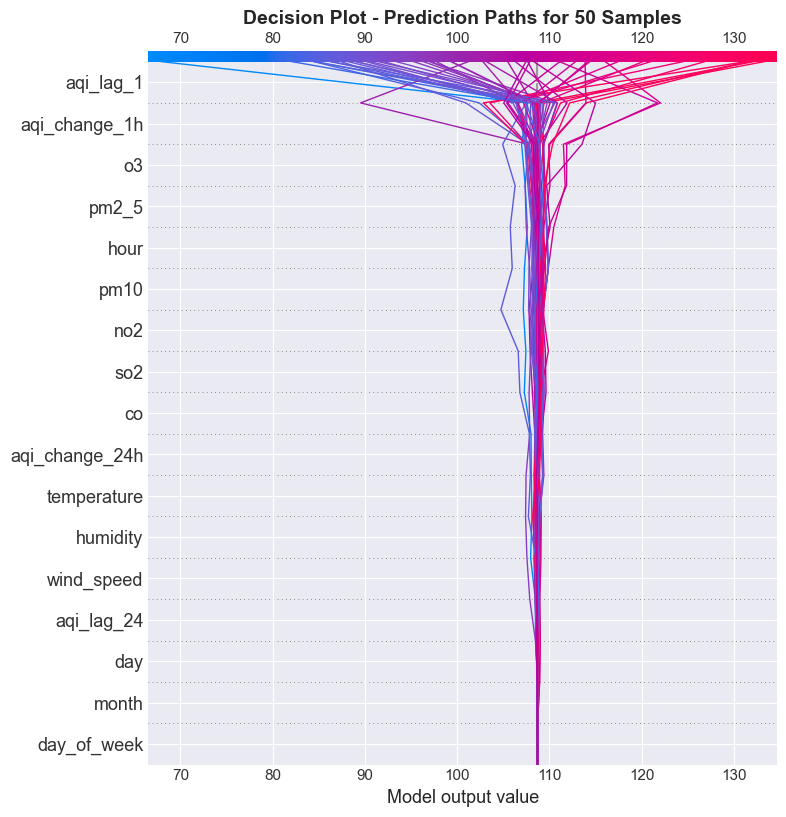

✅ Saved: figures/shap/09_decision_plot.png

💡 Interpretation:
   - X-axis = cumulative SHAP value
   - Y-axis = features (ordered by importance)
   - Each line = one prediction's journey
   - Spread shows how features affect different predictions


In [22]:
# Decision plot for multiple samples
print("📊 Generating Decision Plot for 50 samples...\n")

sample_indices = np.random.choice(len(X_test_sample), size=50, replace=False)

plt.figure(figsize=(12, 10))
shap.decision_plot(
    explainer.expected_value,
    shap_values[sample_indices],
    X_test_sample.iloc[sample_indices],
    show=False
)
plt.title("Decision Plot - Prediction Paths for 50 Samples", 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/shap/09_decision_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: figures/shap/09_decision_plot.png")
print("\n💡 Interpretation:")
print("   - X-axis = cumulative SHAP value")
print("   - Y-axis = features (ordered by importance)")
print("   - Each line = one prediction's journey")
print("   - Spread shows how features affect different predictions")

## 10. Business Insights & Recommendations

Let's extract actionable insights from SHAP analysis.

In [23]:
print("\n" + "="*80)
print("💡 KEY INSIGHTS FROM SHAP ANALYSIS")
print("="*80)

# 1. Feature importance ranking
print("\n1️⃣ FEATURE IMPORTANCE RANKING:")
print("-" * 60)
for idx, row in feature_importance_df.head(10).iterrows():
    pct = (row['importance'] / feature_importance_df['importance'].sum()) * 100
    print(f"   {idx+1:2d}. {row['feature']:20s} → {row['importance']:.4f} ({pct:.1f}%)")

# 2. Expected insights
print("\n2️⃣ EXPECTED INSIGHTS (validate with your data):")
print("-" * 60)

top_feature = feature_importance_df.iloc[0]['feature']

if 'aqi_lag_1' in feature_importance_df.head(3)['feature'].values:
    print("   ✅ aqi_lag_1 is highly important (as expected)")
    print("      → AQI is highly autocorrelated (current AQI predicts next hour)")
    print("      → Recommendation: Maintain hourly data collection")
else:
    print("   ⚠️ aqi_lag_1 NOT in top 3 - investigate data quality")

if 'pm2_5' in feature_importance_df.head(5)['feature'].values:
    print("\n   ✅ PM2.5 is important (as expected)")
    print("      → PM2.5 is major driver of AQI in Karachi")
    print("      → Recommendation: Focus air quality interventions on PM2.5 sources")
else:
    print("\n   ⚠️ PM2.5 NOT highly ranked - check correlation with AQI")

if 'wind_speed' in feature_importance_df.head(10)['feature'].values:
    print("\n   ✅ Wind speed is relevant")
    print("      → Wind disperses pollution")
    print("      → Recommendation: Include weather forecasts in predictions")

# 3. Model reliability
print("\n3️⃣ MODEL RELIABILITY ASSESSMENT:")
print("-" * 60)

top_3_importance = feature_importance_df.head(3)['importance'].sum()
total_importance = feature_importance_df['importance'].sum()
top_3_pct = (top_3_importance / total_importance) * 100

print(f"   Top 3 features explain {top_3_pct:.1f}% of predictions")

if top_3_pct > 80:
    print("   ✅ Model relies on few strong predictors (good for interpretability)")
elif top_3_pct < 40:
    print("   ⚠️ Predictions distributed across many features (complex model)")
else:
    print("   ✅ Balanced feature importance (healthy model)")

# 4. Actionable recommendations
print("\n4️⃣ ACTIONABLE RECOMMENDATIONS:")
print("-" * 60)

recommendations = [
    "📊 Monitor top 5 features closely in production",
    "🔄 Ensure hourly data pipeline never fails (lag features critical)",
    "🌤️ Integrate weather forecasts for better predictions",
    "🚨 Set alerts based on feature thresholds (e.g., PM2.5 > 100)",
    "📈 Track feature importance over time (detect concept drift)",
    "🧪 A/B test interventions on high-impact features",
    "📝 Document feature engineering decisions for reproducibility"
]

for i, rec in enumerate(recommendations, 1):
    print(f"   {i}. {rec}")

print("\n" + "="*80)


💡 KEY INSIGHTS FROM SHAP ANALYSIS

1️⃣ FEATURE IMPORTANCE RANKING:
------------------------------------------------------------
   14. aqi_lag_1            → 15.4895 (76.3%)
   16. aqi_change_1h        → 2.5023 (12.3%)
    4. o3                   → 0.4301 (2.1%)
    1. pm2_5                → 0.3632 (1.8%)
    2. pm10                 → 0.2090 (1.0%)
   10. hour                 → 0.1989 (1.0%)
   17. aqi_change_24h       → 0.1876 (0.9%)
    3. no2                  → 0.1844 (0.9%)
    6. so2                  → 0.1290 (0.6%)
    7. temperature          → 0.1231 (0.6%)

2️⃣ EXPECTED INSIGHTS (validate with your data):
------------------------------------------------------------
   ✅ aqi_lag_1 is highly important (as expected)
      → AQI is highly autocorrelated (current AQI predicts next hour)
      → Recommendation: Maintain hourly data collection

   ✅ PM2.5 is important (as expected)
      → PM2.5 is major driver of AQI in Karachi
      → Recommendation: Focus air quality interventions

## 11. Validation & Sanity Checks

In [26]:
print("\n🔍 SHAP VALIDATION CHECKS")
print("="*80)


base_value = (
    float(explainer.expected_value[0]) 
    if isinstance(explainer.expected_value, np.ndarray) 
    else float(explainer.expected_value)
)

# Check 1: SHAP values sum to prediction
sample_pred = model.predict(X_test_sample.iloc[[0]])[0]
shap_sum = base_value + shap_values[0].sum()  # ⭐ Now both are scalars
difference = abs(sample_pred - shap_sum)

print(f"\n✅ Check 1: SHAP values sum to prediction")
print(f"   Model prediction: {sample_pred:.4f}")
print(f"   SHAP sum:         {shap_sum:.4f}")
print(f"   Difference:       {difference:.6f}")

if difference < 0.01:
    print("   ✅ PASS: SHAP values correctly decompose prediction")
else:
    print("   ⚠️ WARNING: Large difference - check explainer")

# Check 2: Feature importance matches expected patterns
print(f"\n✅ Check 2: Lag features in top 5")
lag_features = ['aqi_lag_1', 'aqi_lag_24']
lag_in_top5 = any(f in feature_importance_df.head(5)['feature'].values for f in lag_features)

if lag_in_top5:
    print("   ✅ PASS: At least one lag feature in top 5 (expected)")
else:
    print("   ⚠️ WARNING: No lag features in top 5 - investigate data")

# Check 3: SHAP values distribution
print(f"\n✅ Check 3: SHAP values distribution")
shap_mean = float(shap_values.mean())  # ⭐ Ensure scalar
shap_std = float(shap_values.std())    # ⭐ Ensure scalar

print(f"   Mean SHAP: {shap_mean:.4f}")
print(f"   Std SHAP:  {shap_std:.4f}")

if abs(shap_mean) < 0.1:
    print("   ✅ PASS: Mean SHAP close to 0 (balanced)")
else:
    print("   ⚠️ INFO: Non-zero mean - check data scaling")

# Check 4: High correlation features
print(f"\n✅ Check 4: Pollutant importance")
pollutants = ['pm2_5', 'pm10', 'no2', 'o3', 'so2', 'co']
pollutant_importance = feature_importance_df[
    feature_importance_df['feature'].isin(pollutants)
]

if len(pollutant_importance) > 0:
    top_pollutant = pollutant_importance.iloc[0]
    print(f"   Top pollutant: {top_pollutant['feature']} (rank {pollutant_importance.index[0]+1})")
    print(f"   ✅ PASS: Pollutants are important features")
else:
    print("   ⚠️ WARNING: No pollutants in top features - check data quality")

print("\n" + "="*80)
print("✅ VALIDATION COMPLETE")
print("="*80)


🔍 SHAP VALIDATION CHECKS

✅ Check 1: SHAP values sum to prediction
   Model prediction: 91.4456
   SHAP sum:         91.4456
   Difference:       0.000000
   ✅ PASS: SHAP values correctly decompose prediction

✅ Check 2: Lag features in top 5
   ✅ PASS: At least one lag feature in top 5 (expected)

✅ Check 3: SHAP values distribution
   Mean SHAP: -0.3965
   Std SHAP:  4.5190
   ⚠️ INFO: Non-zero mean - check data scaling

✅ Check 4: Pollutant importance
   Top pollutant: o3 (rank 4)
   ✅ PASS: Pollutants are important features

✅ VALIDATION COMPLETE


## 12. Export Results

In [27]:
# Export feature importance to CSV
feature_importance_df.to_csv('figures/shap/feature_importance.csv', index=False)
print("✅ Saved: figures/shap/feature_importance.csv")

# Create summary report
summary_report = {
    'analysis_date': datetime.now().isoformat(),
    'samples_analyzed': len(X_test_sample),
    'top_3_features': feature_importance_df.head(3)['feature'].tolist(),
    'top_3_importance': feature_importance_df.head(3)['importance'].tolist(),
    'model_performance': {
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_r2': test_r2
    }
}

import json
with open('figures/shap/summary_report.json', 'w') as f:
    json.dump(summary_report, f, indent=2)

print("✅ Saved: figures/shap/summary_report.json")

# List all generated files
print("\n📂 Generated Files:")
print("="*60)
import os
for file in sorted(os.listdir('figures/shap')):
    if file.endswith(('.png', '.csv', '.json')):
        filepath = os.path.join('figures/shap', file)
        size_kb = os.path.getsize(filepath) / 1024
        print(f"   {file:40s} ({size_kb:6.1f} KB)")

✅ Saved: figures/shap/feature_importance.csv
✅ Saved: figures/shap/summary_report.json

📂 Generated Files:
   01_feature_importance_bar.png            ( 151.2 KB)
   02_summary_beeswarm.png                  ( 272.1 KB)
   03_dependence_plots.png                  ( 893.8 KB)
   04_force_plot_high_aqi.png               ( 119.9 KB)
   05_force_plot_low_aqi.png                ( 112.9 KB)
   06_waterfall_high_aqi.png                ( 177.2 KB)
   07_waterfall_low_aqi.png                 ( 174.0 KB)
   08_feature_interaction.png               ( 168.9 KB)
   09_decision_plot.png                     ( 427.9 KB)
   feature_importance.csv                   (   0.5 KB)
   summary_report.json                      (   0.4 KB)
